# 00 · EDA

Revisar los originales y los resultados de la ingesta. Este notebook solo lee datos.

La primera parte usa data/raw/. La revisión del texto requiere ejecutar 01 y volver a este notebook. Los conteos describen lo descargado.

In [12]:
import hashlib
import json
from pathlib import Path
from urllib.parse import urlsplit

import pandas as pd
from IPython.display import display

RAIZ = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / "data/raw/manifest.json").is_file()), None)
if RAIZ is None:
    raise FileNotFoundError("Abre este notebook desde la carpeta del proyecto.")
RAW = RAIZ / "data" / "raw"
manifest = json.loads((RAW / "manifest.json").read_text(encoding="utf-8"))
documentos = pd.DataFrame([{k: v for k, v in d.items() if k != "archivos_raw"}
                          for d in manifest])
archivos = pd.DataFrame([dict(a, doc_id=d["doc_id"])
                        for d in manifest for a in d["archivos_raw"]])

## 1. Inventario

In [13]:
archivos["formato"] = archivos["archivo"].map(lambda p: Path(p).suffix.lower())
display(pd.Series({
    "Documentos": len(documentos),
    "Archivos": len(archivos),
    "Tamaño declarado (MiB)": round(archivos["bytes"].sum() / 1024**2, 2),
}, name="Inventario").to_frame())
display(archivos["formato"].value_counts().rename("archivos").to_frame())
display(documentos[["doc_id", "titulo", "fuente", "url"]].head(5))

,Inventario
Documentos,282.00
Archivos,282.00
Tamaño declarado (MiB),116.85


,archivos
formato,
.html,241
.pdf,41


,doc_id,titulo,fuente,url
0,auto_cc_a841_2025,Auto 841 de 2025 - Ley 2381 de 2024,Corte Constitucional - Relatoría,https://www.corteconstitucional.gov.co/relator...
1,co_constitucion_1_1991,Constitución Política de Colombia,Departamento Administrativo de la Función Públ...,https://www.funcionpublica.gov.co/eva/gestorno...
2,co_decreto_1069_2015,Decreto Único Reglamentario del Sector Justici...,Departamento Administrativo de la Función Públ...,https://www.funcionpublica.gov.co/eva/gestorno...
3,co_decreto_1082_2015,Decreto Único Reglamentario del Sector Adminis...,Departamento Administrativo de la Función Públ...,https://www.funcionpublica.gov.co/eva/gestorno...
4,co_decreto_1083_2015,Decreto Único Reglamentario del Sector de Func...,Departamento Administrativo de la Función Públ...,https://www.funcionpublica.gov.co/eva/gestorno...


## 2. Cobertura

Un documento puede pertenecer a varias áreas. La suma por área puede superar el total.

In [14]:
display(documentos["areas"].explode().value_counts().rename("documentos").to_frame())
display(documentos["tipo"].value_counts().rename("documentos").to_frame())
display(documentos["anio"].value_counts().sort_index().rename("documentos").to_frame())
dominios = documentos["url"].map(lambda url: urlsplit(url).netloc.lower())
display(dominios.value_counts().rename("documentos por dominio").to_frame())

# Un documento puede tener varias áreas.
por_area = documentos.explode("areas", ignore_index=True)
display(pd.crosstab(por_area["areas"], por_area["tipo"]))

,documentos
areas,
constitucional,74
procesal,55
administrativo,44
laboral,43
penal,40
civil,38
familia,30
mercados,25
tributario,20


,documentos
tipo,
ley,171
sentencia,84
decreto,23
decision,2
auto,1
constitucion,1


,documentos
anio,
1873,1
1887,2
1890,1
1932,1
1936,1
1948,1
1950,1
1959,1
1968,1


,documentos por dominio
url,
www.funcionpublica.gov.co,198
www.corteconstitucional.gov.co,47
cortesuprema.gov.co,18
www.cancilleria.gov.co,2
normas.cra.gov.co,2
normograma.dian.gov.co,2
www.consejodeestado.gov.co,2
www.mintic.gov.co,1
normograma.superservicios.gov.co,1


tipo,auto,constitucion,decision,decreto,ley,sentencia
areas,,,,,,
administrativo,0,1,0,4,28,11
civil,0,0,0,2,17,19
comercial_sociedades,0,0,0,3,13,1
constitucional,1,1,0,4,21,47
familia,0,0,0,0,24,6
laboral,1,0,0,5,23,14
mercados,0,0,2,2,16,5
penal,0,0,0,0,31,9
procesal,0,1,0,4,20,30


## 3. Metadatos y procedencia

La fecha de consulta no demuestra vigencia. Los originales marcados `redistribuir_raw=False` requieren revisar sus anotaciones antes de publicarlos.

In [15]:
campos = ["doc_id", "titulo", "tipo", "numero", "anio", "organo_emisor",
          "areas", "fuente", "url", "fecha_consulta", "vigencia", "licencia_fuente"]
faltantes = pd.Series({campo: sum(d.get(campo) in (None, "", []) for d in manifest)
                      for campo in campos}, name="faltantes")
display(faltantes.to_frame())
display(documentos.loc[documentos["doc_id"].duplicated(keep=False), ["doc_id", "titulo"]])
display(archivos.loc[archivos["sha256"].duplicated(keep=False), ["doc_id", "archivo", "sha256"]])
display(documentos["vigencia"].value_counts().rename("documentos").to_frame())
revisar_publicacion = documentos.loc[documentos["redistribuir_raw"] != True,
                                    ["doc_id", "titulo", "redistribuir_raw", "edicion_con_anotaciones"]]
display(revisar_publicacion)

,faltantes
doc_id,0
titulo,0
tipo,0
numero,0
anio,0
organo_emisor,0
areas,0
fuente,0
url,0
fecha_consulta,0


,doc_id,titulo


,doc_id,archivo,sha256


,documentos
vigencia,
por_verificar,275
alcance_y_efectos_de_la_providencia,5
requiere_control_temporal_A841_2025_C264_2026,1
consultar_decision_C481_2019_y_efectos_temporales,1


,doc_id,titulo,redistribuir_raw,edicion_con_anotaciones
35,decision_351_1993,Régimen común sobre derecho de autor y derecho...,False,True
36,decision_486_2000,Régimen común de propiedad industrial,False,True
62,ley_1835_2017,Remuneración a autores de obras cinematográficas,False,True
63,ley_1878_2018,Modificaciones al Código de Infancia y Adolesc...,False,True
67,ley_2089_2021,"Prohibición del castigo físico a niñas, niños ...",False,True
89,ley_675_2001,Régimen de propiedad horizontal,False,True
94,ley_84_1873,Código Civil colombiano,False,True
218,ley_1943_2018,Ley de financiamiento de 2018; fuente histórica,False,True
241,ley_28_1932,Régimen patrimonial en el matrimonio,False,True
265,sentencia_ce_suj4005_2020,2020CE-SUJ-4-005 - Deducciones tributarias,False,True


## 4. Integridad

Comparar cada archivo con su tamaño y SHA-256 registrados. Esto verifica la copia, no la corrección jurídica.

In [16]:
def revisar_archivo(archivo):
    ruta = (RAW / archivo["archivo"]).resolve()
    if not ruta.is_relative_to(RAW.resolve()):
        return "ruta fuera de raw"
    if not ruta.is_file():
        return "no encontrado"
    contenido = ruta.read_bytes()
    if not contenido:
        return "vacío"
    if len(contenido) != archivo["bytes"]:
        return "tamaño distinto"
    if hashlib.sha256(contenido).hexdigest() != archivo["sha256"]:
        return "hash distinto"
    return "ok"

integridad = archivos[["doc_id", "archivo"]].copy()
integridad["estado"] = [revisar_archivo(a) for a in archivos.to_dict("records")]
display(integridad["estado"].value_counts().rename("archivos").to_frame())
display(integridad.loc[integridad["estado"] != "ok"])

,archivos
estado,
ok,282


,doc_id,archivo,estado


## Resumen de la ejecución

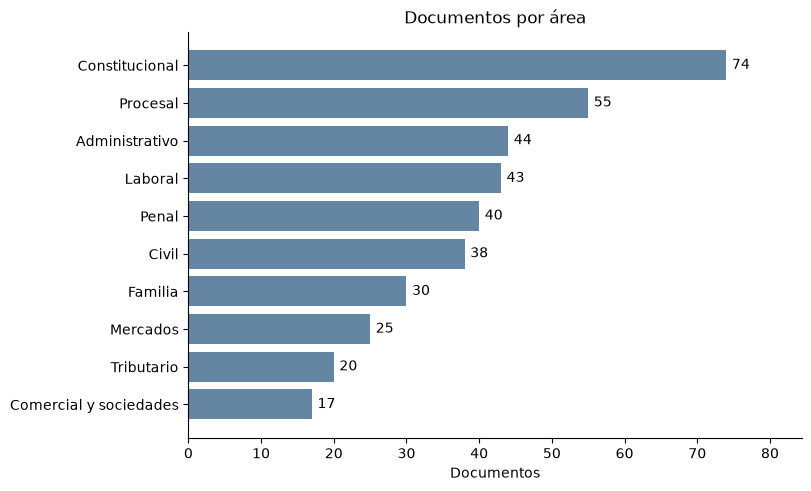

,Total
Documentos,282
Archivos íntegros,282
Campos faltantes,0
Identificadores duplicados,0
Archivos idénticos,0
Vigencia por verificar,275
Publicación por revisar,10


In [17]:
import matplotlib.pyplot as plt

documentos_por_area = documentos["areas"].explode().value_counts().sort_values()
nombres_areas = {
    "constitucional": "Constitucional",
    "administrativo": "Administrativo",
    "penal": "Penal",
    "procesal": "Procesal",
    "comercial_sociedades": "Comercial y sociedades",
    "civil": "Civil",
    "familia": "Familia",
    "tributario": "Tributario",
    "laboral": "Laboral",
    "mercados": "Mercados",
}
fig, ax = plt.subplots(figsize=(8, 4.8), layout="constrained")
barras = ax.barh(documentos_por_area.index.map(nombres_areas), documentos_por_area.values,
                 color="#6486a3")
ax.bar_label(barras, padding=4)
ax.set_title("Documentos por área")
ax.set_xlabel("Documentos")
ax.set_xlim(0, documentos_por_area.max() * 1.14)
ax.spines[["top", "right"]].set_visible(False)
plt.show()

display(pd.Series({
    "Documentos": len(documentos),
    "Archivos íntegros": int((integridad["estado"] == "ok").sum()),
    "Campos faltantes": int(faltantes.sum()),
    "Identificadores duplicados": int(documentos["doc_id"].duplicated().sum()),
    "Archivos idénticos": int(archivos["sha256"].duplicated().sum()),
    "Vigencia por verificar": int((documentos["vigencia"] == "por_verificar").sum()),
    "Publicación por revisar": len(revisar_publicacion),
}, name="Total").to_frame())

## Resultados del inventario

Se revisaron 282 documentos de 10 áreas. Son 241 HTML y 41 PDF.

Los 282 archivos coinciden con sus hashes. No se encontraron archivos idénticos por hash ni faltantes en los campos revisados. Esto no descarta textos similares o versiones de una misma norma.

Hay 275 registros etiquetados como vigencia por verificar y 10 originales con condiciones de publicación por revisar. Los otros 7 registros tampoco certifican vigencia. La revisión jurídica sigue pendiente en los 282 documentos.

## Decisiones

- Conservar los originales y guardar los derivados en data/processed/.
- Mantener las señales de vigencia y las notas de cada fuente.
- Revisar los avisos antes de usar o publicar el corpus.
- Usar los conteos por área para orientar la ampliación. No indican cuánto cubrimos de la evaluación.

## 5. Calidad del texto procesado

Esta parte usa las salidas de 01. Si no existen o el manifiesto cambió, se omite y se indica el motivo.

Se revisan longitudes antes y después de segmentar, repeticiones y avisos. Un hash correcto confirma la copia. No confirma que los artículos estén bien separados.

In [18]:
PROCESADOS = RAIZ / "data/processed/corpus"
necesarios = ["resumen.json", "documentos.jsonl", "unidades.jsonl", "fragmentos.jsonl"]
procesados_disponibles = all((PROCESADOS / nombre).is_file() for nombre in necesarios)

if procesados_disponibles:
    resumen_ingesta = json.loads((PROCESADOS / "resumen.json").read_text(encoding="utf-8"))
    hash_manifest = hashlib.sha256((RAW / "manifest.json").read_bytes()).hexdigest()
    procesados_disponibles = resumen_ingesta.get("sha256_manifest") == hash_manifest
    if not procesados_disponibles:
        print("El manifiesto cambió. Repetir 01 antes de revisar sus salidas.")
else:
    print("Faltan salidas de la ingesta. Ejecutar 01 y volver al EDA.")


def leer_columnas(nombre, campos):
    filas = []
    with (PROCESADOS / nombre).open(encoding="utf-8") as archivo:
        for linea in archivo:
            fila = json.loads(linea)
            filas.append({campo: fila[campo] for campo in campos})
    return pd.DataFrame(filas)


if procesados_disponibles:
    docs = leer_columnas("documentos.jsonl", ["doc_id", "caracteres", "estado_extraccion", "sha256_texto"])
    unidades = leer_columnas("unidades.jsonl", ["doc_id", "unidad_id", "tipo_unidad", "articulo", "texto", "estado_segmentacion", "avisos"])
    ventanas = leer_columnas("fragmentos.jsonl", ["doc_id", "inicio", "fin"])
    unidades["caracteres"] = unidades["texto"].str.len()
    ventanas["caracteres"] = ventanas["fin"] - ventanas["inicio"]
    display(pd.DataFrame({
        "Documentos": docs["caracteres"].describe(percentiles=[.5, .95, .99]),
        "Unidades": unidades["caracteres"].describe(percentiles=[.5, .95, .99]),
        "Ventanas": ventanas["caracteres"].describe(percentiles=[.5, .95, .99]),
    }).round(1))
    display(unidades.groupby("tipo_unidad")["caracteres"].agg(
        cantidad="size", minimo="min", mediana="median",
        p95=lambda x: x.quantile(.95), maximo="max",
    ).round(1))

,Documentos,Unidades,Ventanas
count,282.0,45242.0,65649.0
mean,213894.0,1333.2,979.1
std,381967.2,4926.6,661.6
min,2848.0,6.0,5.0
50%,80743.5,556.0,830.0
95%,948084.4,3779.9,1799.0
99%,1709417.4,14370.7,1800.0
max,3296993.0,306707.0,1800.0


,cantidad,minimo,mediana,p95,maximo
tipo_unidad,,,,,
articulo,29144,28,602.0,3044.0,36017
encabezado_ambiguo,4904,12,769.0,3950.8,39046
parrafo,5788,6,666.5,15382.6,306707
preambulo,282,52,380.5,22678.1,96142
seccion,5124,6,50.0,2381.5,196299


### Longitudes y valores atípicos

Comparar las unidades dentro de su tipo. El criterio de 1.5 veces el rango intercuartílico señala casos para revisar. No demuestra que estén mal y no se usa para borrarlos.

Las ventanas tienen un límite de 1800 caracteres. El pico junto al límite es esperado. Para detectar cortes incorrectos también hay que mirar las unidades completas y leer ejemplos.

,unidades,atipicas
tipo_unidad,,
articulo,29144,2469
encabezado_ambiguo,4904,391
parrafo,5788,876
preambulo,282,60
seccion,5124,605


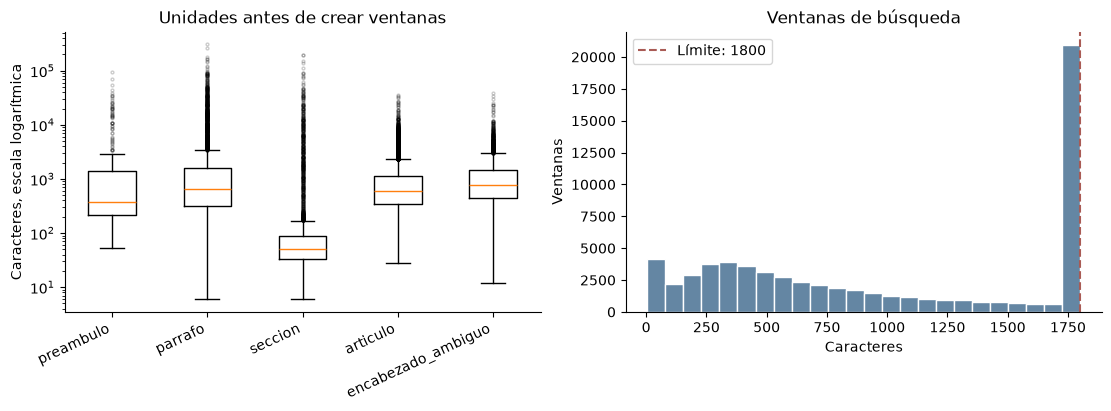

,doc_id,unidad_id,tipo_unidad,articulo,caracteres
40153,sentencia_cc_c055_2022,sentencia_cc_c055_2022__u00534,parrafo,NaN,306707
40554,sentencia_cc_c1011_2008,sentencia_cc_c1011_2008__u00071,parrafo,NaN,259436
43611,sentencia_cc_su337_1999,sentencia_cc_su337_1999__u00005,seccion,NaN,196299
42806,sentencia_cc_c748_2011,sentencia_cc_c748_2011__u00073,seccion,NaN,196085
42915,sentencia_cc_c776_2003,sentencia_cc_c776_2003__u00075,parrafo,NaN,179329
42451,sentencia_cc_c577_2011,sentencia_cc_c577_2011__u00044,parrafo,NaN,167748
41705,sentencia_cc_c481_2019,sentencia_cc_c481_2019__u00009,parrafo,NaN,162800
43568,sentencia_cc_su214_2016,sentencia_cc_su214_2016__u00043,parrafo,NaN,154590
43103,sentencia_cc_su047_1999,sentencia_cc_su047_1999__u00009,seccion,NaN,152614
44016,sentencia_cc_t760_2008,sentencia_cc_t760_2008__u00013,parrafo,NaN,145527


,doc_id,unidad_id,tipo_unidad,articulo,caracteres,inicio_texto
39215,sentencia_cc_c029_2009,sentencia_cc_c029_2009__u00120,parrafo,NaN,6,2. El\n
40444,sentencia_cc_c075_2007,sentencia_cc_c075_2007__u00033,parrafo,NaN,6,3. El\n
42447,sentencia_cc_c577_2011,sentencia_cc_c577_2011__u00040,parrafo,NaN,6,1. La\n
44556,sentencia_ce_suj4002_2021,sentencia_ce_suj4002_2021__u00005,seccion,NaN,6,FALLA\n
44574,sentencia_ce_suj4005_2020,sentencia_ce_suj4005_2020__u00011,seccion,NaN,6,FALLA\n
2355,co_decreto_1082_2015,co_decreto_1082_2015__u00018,seccion,NaN,8,PARTE 1\n
3557,co_decreto_1082_2015,co_decreto_1082_2015__u01220,seccion,NaN,8,LIBRO 3\n
3568,co_decreto_1083_2015,co_decreto_1083_2015__u00007,seccion,NaN,8,PARTE 1\n
8489,decreto_1072_2015,decreto_1072_2015__u00029,seccion,NaN,8,PARTE 1\n
10000,decreto_1072_2015,decreto_1072_2015__u01540,seccion,NaN,8,LIBRO 3\n


In [19]:
if procesados_disponibles:
    q1 = unidades.groupby("tipo_unidad")["caracteres"].transform(lambda x: x.quantile(.25))
    q3 = unidades.groupby("tipo_unidad")["caracteres"].transform(lambda x: x.quantile(.75))
    iqr = q3 - q1
    unidades["atipica_iqr"] = (unidades["caracteres"] < q1 - 1.5 * iqr) | (unidades["caracteres"] > q3 + 1.5 * iqr)
    display(unidades.groupby("tipo_unidad")["atipica_iqr"].agg(unidades="size", atipicas="sum"))

    tipos = unidades["tipo_unidad"].unique()
    fig, axes = plt.subplots(1, 2, figsize=(11, 4), layout="constrained")
    axes[0].boxplot([unidades.loc[unidades["tipo_unidad"] == tipo, "caracteres"] for tipo in tipos],
                    flierprops={"markersize": 2, "alpha": .2})
    axes[0].set_xticks(range(1, len(tipos) + 1), tipos, rotation=25, ha="right")
    axes[0].set_yscale("log")
    axes[0].set_title("Unidades antes de crear ventanas")
    axes[0].set_ylabel("Caracteres, escala logarítmica")
    axes[1].hist(ventanas["caracteres"], bins=24, color="#6486a3", edgecolor="white")
    limite = resumen_ingesta["parametros_segmentacion"]["max_caracteres"]
    axes[1].axvline(limite, color="#a95b55", linestyle="--", label=f"Límite: {limite}")
    axes[1].set_title("Ventanas de búsqueda")
    axes[1].set_xlabel("Caracteres")
    axes[1].set_ylabel("Ventanas")
    axes[1].legend()
    for ax in axes:
        ax.spines[["top", "right"]].set_visible(False)
    plt.show()

    columnas = ["doc_id", "unidad_id", "tipo_unidad", "articulo", "caracteres"]
    display(unidades.nlargest(10, "caracteres")[columnas])
    cortas = unidades.nsmallest(10, "caracteres").copy()
    cortas["inicio_texto"] = cortas["texto"].str[:120]
    display(cortas[columnas + ["inicio_texto"]])

### Repeticiones, concentración y avisos

Se comparan textos idénticos. Los encabezados repetidos pueden ser válidos y esta revisión no detecta duplicados semánticos.

La concentración muestra cuánto aportan los documentos más largos al índice. No mide la cobertura de las preguntas. Los avisos de extracción y segmentación se cuentan por separado.

In [20]:
if procesados_disponibles:
    unidades["sha256_texto"] = unidades["texto"].map(lambda t: hashlib.sha256(t.encode("utf-8")).hexdigest())
    repetidas = unidades[unidades["sha256_texto"].duplicated(keep=False)]
    aporte = ventanas["doc_id"].value_counts().rename("ventanas").to_frame()
    aporte["porcentaje"] = (100 * aporte["ventanas"] / len(ventanas)).round(2)
    display(aporte.head(10))
    display(pd.Series({
        "Documentos de texto idéntico, copias adicionales": int(docs["sha256_texto"].duplicated().sum()),
        "Unidades en grupos de texto idéntico": len(repetidas),
        "Grupos de unidades idénticas": repetidas["sha256_texto"].nunique(),
        "Unidades de menos de 80 caracteres": int(unidades["caracteres"].lt(80).sum()),
        "Aporte de los 10 documentos con más ventanas (%)": round(100 * aporte["ventanas"].head(10).sum() / len(ventanas), 2),
    }, name="Resultado").to_frame())
    ejemplos_repetidos = repetidas.groupby("sha256_texto").agg(
        repeticiones=("unidad_id", "size"), documentos=("doc_id", "nunique"), texto=("texto", "first"),
    ).nlargest(5, "repeticiones")
    display(ejemplos_repetidos.reset_index(drop=True))

    revision = docs[["doc_id", "estado_extraccion"]].copy()
    ids_segmentacion = set(unidades.loc[unidades["estado_segmentacion"] == "revisar", "doc_id"])
    ids_avisos = set(unidades.loc[unidades["avisos"].map(bool), "doc_id"])
    revision["segmentacion"] = revision["doc_id"].isin(ids_segmentacion).map({True: "Con revisión", False: "Sin revisión marcada"})
    display(pd.crosstab(revision["estado_extraccion"], revision["segmentacion"]))
    display(pd.Series({
        "Documentos con avisos de extracción": int(docs["estado_extraccion"].eq("revisar").sum()),
        "Documentos con segmentación por revisar": len(ids_segmentacion),
        "Documentos con algún aviso en sus unidades": len(ids_avisos),
    }, name="Documentos").to_frame())

,ventanas,porcentaje
doc_id,,
decreto_1625_2016,3255,4.96
ley_84_1873,2947,4.49
decreto_1074_2015,2942,4.48
decreto_410_1971,2314,3.52
co_decreto_1069_2015,1942,2.96
decreto_624_1989,1827,2.78
decreto_1072_2015,1802,2.74
co_decreto_1082_2015,1526,2.32
sentencia_cc_c355_2006,1424,2.17


,Resultado
"Documentos de texto idéntico, copias adicionales",0.00
Unidades en grupos de texto idéntico,890.00
Grupos de unidades idénticas,278.00
Unidades de menos de 80 caracteres,4128.00
Aporte de los 10 documentos con más ventanas (%),32.54


,repeticiones,documentos,texto
0,73,32,DISPOSICIONES GENERALES\n
1,42,26,DISPOSICIONES FINALES\n
2,30,6,SECCIÓN 1\n
3,21,15,Disposiciones generales\n
4,19,14,CAPÍTULO I\n


segmentacion,Con revisión,Sin revisión marcada
estado_extraccion,,
extraido,140,91
revisar,10,41


,Documentos
Documentos con avisos de extracción,51
Documentos con segmentación por revisar,150
Documentos con algún aviso en sus unidades,191


### Lectura de casos

Buscar encabezados de artículo partidos entre líneas ayuda a localizar posibles uniones incorrectas. También puede encontrar artículos citados. La coincidencia no decide la atribución.

El decreto 306 de 1992 permite revisar un fallo concreto. La extracción conserva varios encabezados, pero la segmentación actual solo asigna el artículo 1.

In [21]:
if procesados_disponibles:
    patron = r"(?im)^[ \t]*ART[IÍ]CULO[ \t]*\n[ \t]*\d"
    unidades["encabezados_partidos"] = unidades["texto"].str.count(patron)
    candidatos = unidades[unidades["encabezados_partidos"] > 0]
    display(candidatos.nlargest(10, "encabezados_partidos")[
        ["doc_id", "unidad_id", "tipo_unidad", "articulo", "encabezados_partidos"]
    ])
    caso = unidades[unidades["doc_id"] == "co_decreto_306_1992"]
    display(caso[["unidad_id", "tipo_unidad", "articulo", "caracteres"]])
    import re
    for texto in caso["texto"]:
        for encabezado in list(re.finditer(patron, texto))[:2]:
            print(texto[encabezado.start():encabezado.start() + 180])
            print()

,doc_id,unidad_id,tipo_unidad,articulo,encabezados_partidos
41027,sentencia_cc_c264_2026,sentencia_cc_c264_2026__u00073,parrafo,NaN,56
24130,ley_130_1994,ley_130_1994__u00013,seccion,NaN,14
24126,ley_130_1994,ley_130_1994__u00009,seccion,NaN,10
4053,co_decreto_2591_1991,co_decreto_2591_1991__u00003,articulo,1,9
41028,sentencia_cc_c264_2026,sentencia_cc_c264_2026__u00074,parrafo,NaN,9
41052,sentencia_cc_c264_2026,sentencia_cc_c264_2026__u00098,parrafo,NaN,9
41431,sentencia_cc_c355_2006,sentencia_cc_c355_2006__u00365,parrafo,NaN,9
42735,sentencia_cc_c748_2011,sentencia_cc_c748_2011__u00002,seccion,NaN,9
4092,co_decreto_306_1992,co_decreto_306_1992__u00002,articulo,1,8
34547,ley_712_2001,ley_712_2001__u00006,seccion,NaN,8


,unidad_id,tipo_unidad,articulo,caracteres
4091,co_decreto_306_1992__u00001,preambulo,NaN,289
4092,co_decreto_306_1992__u00002,articulo,1,5847


ARTÍCULO
2º- De los derechos protegidos por la acción de tutela. De conformidad con el artículo 1º del Decreto 2591 de 1991, la acción de tutela protege exclusivamente los derechos

ARTÍCULO
3º- De cuando no existe amenaza de un derecho constitucional fundamental. Se entenderá que no se encuentra amenazado un derecho constitucional fundamental por el solo hech



## Resultados de la revisión del texto

Estos resultados corresponden a la última ingesta auditada. Solo aplican si la comprobación del manifiesto pasa y se conservan esas salidas. Si se omite la revisión por datos ausentes o un manifiesto distinto, las cifras siguientes no describen la ejecución actual. Hay que actualizarlas si cambia el corpus o la segmentación.

La mediana de las unidades es de 556 caracteres. La más larga tiene 306707. Hay 4128 unidades de menos de 80 caracteres. Algunas son títulos válidos, pero también aparecen cortes como «2. El».

Hay 890 unidades en 278 grupos de texto idéntico. Entre ellas se repiten encabezados como «DISPOSICIONES GENERALES». Los 10 documentos con más ventanas aportan el 32.54 % del total.

Los 51 documentos con avisos de extracción no eran todos los casos por revisar. Hay 150 con segmentación marcada para revisión y 191 con algún aviso en sus unidades. Los grupos se solapan.

El decreto 306 de 1992 quedó con un preámbulo y una unidad atribuida al artículo 1 que incluye otros artículos. Los controles de integridad no detectaron esta unión.

## Decisiones

- Corregir los encabezados partidos y revisar las unidades demasiado cortas o largas antes de indexar.
- Tratar los valores atípicos como candidatos a revisión. No borrar texto solo por su longitud.
- Asociar los títulos a su contenido para evitar recuperarlos solos como evidencia.
- Revisar las repeticiones manteniendo la procedencia de cada texto.
- Comparar tamaños de ventana con el tokenizer del encoder. Los 1800 caracteres aún no están validados para ese modelo.
- Evaluar recuperación con preguntas y evidencia revisada. Los conteos por área no demuestran cobertura ni permiten anticipar el puntaje.